In [88]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.stats import (
    poisson
)

In [89]:
titanic = pd.read_csv("../../Downloads/Titanic-Dataset.xls")

In [90]:
titanic["Age"].isna().sum()

177

In [91]:
titanic.shape[0]

891

In [92]:
ages = titanic["Age"].fillna(titanic["Age"].mean()).unique()

In [93]:
ages.std()

20.847429535239804

In [94]:
ages.mean()

33.671787838731

In [95]:
spread = ages.mean() - ages.std()

In [96]:
spread

12.824358303491195

In [97]:
ages_skew = skew(ages)
ages_kurtosis = kurtosis(ages)

In [98]:
print(ages_skew,ages_kurtosis)

0.1545725689133376 -0.9328574605069231


In [99]:
## Assume the variable is following different standard random variables

## We want to assume poisson random variable for ages columns

lambda_ = ages.mean()
lambda_

33.671787838731

In [100]:
ages_poission_probs = []
for age in ages:
    prob = poisson.pmf(age,lambda_)
    ages_poission_probs.append(prob)

In [101]:
df = pd.DataFrame({"age":ages,"poisson_prob":ages_poission_probs})
df
## poisson_prob of a person's age being around the lambda_ is more.

,age,poisson_prob
0,22.000000,8.425926e-03
1,38.000000,4.944502e-02
2,26.000000,3.018769e-02
3,35.000000,6.555591e-02
4,29.699118,0.000000e+00
...,...,...
84,0.670000,0.000000e+00
85,30.500000,0.000000e+00
86,0.420000,0.000000e+00
87,34.500000,0.000000e+00


In [102]:
df.sort_values("age",ascending=True,inplace=True)

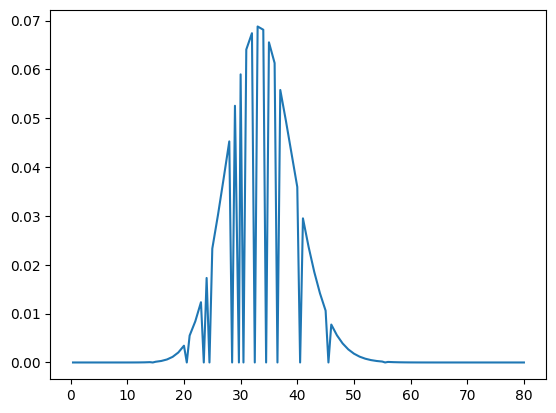

In [103]:
plt.plot(df["age"],df["poisson_prob"])

In [104]:
th_age_poisson_samples = poisson.rvs(lambda_,size = len(ages))
th_age_poisson_samples.sort()

In [105]:
th_age_poisson_probs = poisson.pmf(th_age_poisson_samples,lambda_)

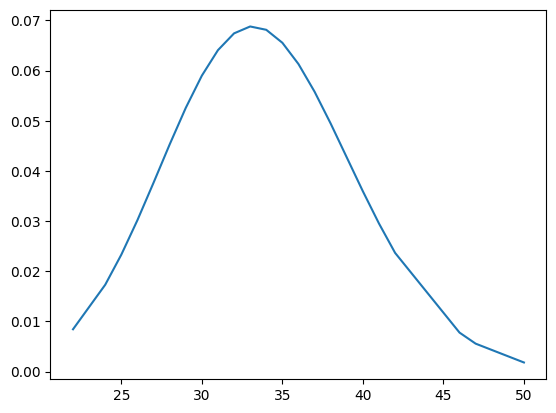

In [106]:
plt.plot(th_age_poisson_samples,th_age_poisson_probs)

In [107]:
l = [1,2,3,4,5]

In [108]:
list(map(lambda x:x**2 + 1,l))

[2, 5, 10, 17, 26]

In [109]:
np.array(l)**2 + 1

array([ 2,  5, 10, 17, 26])

In [110]:
type(np.array(l)) == np.ndarray

True

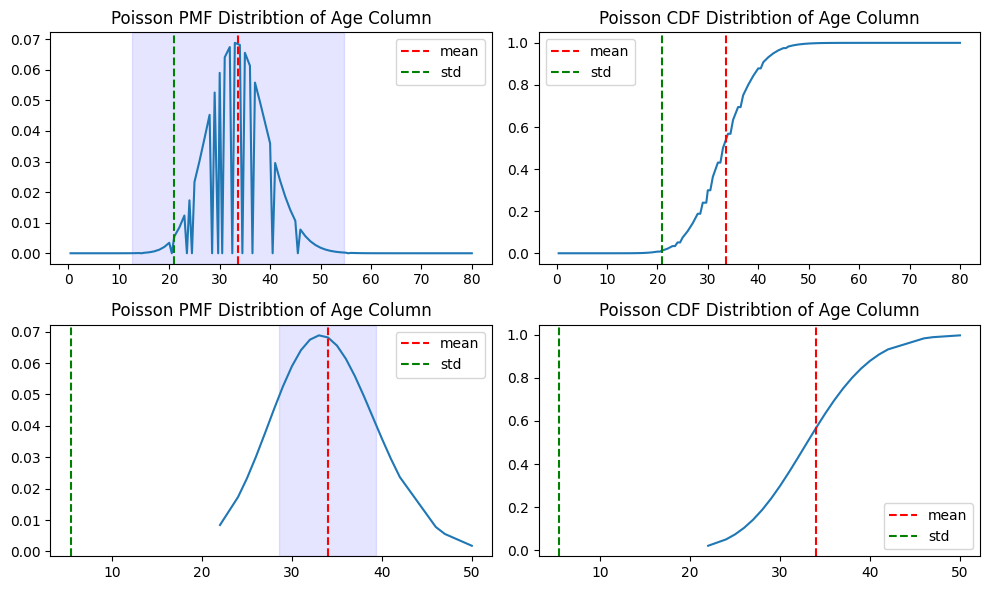

In [113]:
fig,axes = plt.subplots(2,2,figsize=(10,6))
axes[0][0].plot(df["age"],df["poisson_prob"])
axes[0][0].axvline(df["age"].mean(),color="red",linestyle="--",label="mean")
axes[0][0].axvline(df["age"].std(),color="green",linestyle="--",label="std")
axes[0][0].axvspan(abs(df["age"].mean()-df["age"].std()),abs(df["age"].mean()+df["age"].std()),alpha=0.1,color="blue")
axes[0][0].set_title("Poisson PMF Distribtion of Age Column")
axes[0][0].legend()
axes[0][1].plot(df["age"],poisson.cdf(df["age"],lambda_))
axes[0][1].axvline(df["age"].mean(),color="red",linestyle="--",label="mean")
axes[0][1].axvline(df["age"].std(),color="green",linestyle="--",label="std")
axes[0][1].set_title("Poisson CDF Distribtion of Age Column")
axes[0][1].legend()


axes[1][0].plot(th_age_poisson_samples,th_age_poisson_probs)
axes[1][0].axvline(th_age_poisson_samples.mean(),color="red",linestyle="--",label="mean")
axes[1][0].axvline(th_age_poisson_samples.std(),color="green",linestyle="--",label="std")
axes[1][0].axvspan(abs(th_age_poisson_samples.mean()-th_age_poisson_samples.std()),
                   abs(th_age_poisson_samples.mean()+th_age_poisson_samples.std()),alpha=0.1,color="blue")
axes[1][0].set_title("Poisson PMF Distribtion of Age Column")
axes[1][0].legend()
axes[1][1].plot(th_age_poisson_samples,poisson.cdf(th_age_poisson_samples,lambda_))
axes[1][1].axvline(th_age_poisson_samples.mean(),color="red",linestyle="--",label="mean")
axes[1][1].axvline(th_age_poisson_samples.std(),color="green",linestyle="--",label="std")
axes[1][1].set_title("Poisson CDF Distribtion of Age Column")
axes[1][1].legend()
plt.tight_layout()
plt.savefig("age_column_poisson_dist_graph.png")

In [85]:
(28+40)/2

34.0

In [119]:
from scipy.stats import norm
ages_mean = ages.mean()
ages_std = ages.std()
ages_normal_pdfs = []
ages_normal_cdfs = []
ages.sort()
for age in ages:
    ages_normal_pdfs.append(norm.pdf(age,loc=ages_mean, scale=ages_std))
    ages_normal_cdfs.append(norm.cdf(age,loc=ages_mean, scale=ages_std))

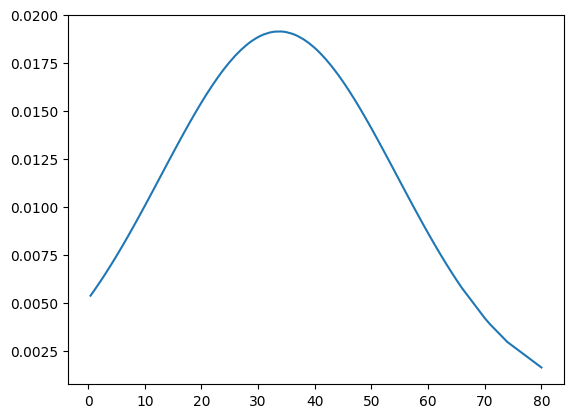

In [120]:
plt.plot(ages,ages_normal_pdfs)

In [124]:
th_norm_samples = norm.rvs(loc=ages_mean,scale=ages_std,size=len(ages))
th_norm_samples.sort()

In [129]:
th_norm_pdfs = norm.pdf(th_norm_samples,loc=th_norm_samples.mean(),scale=th_norm_samples.std())

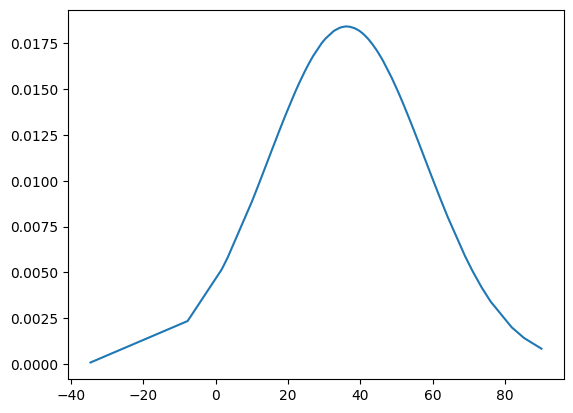

In [130]:
plt.plot(th_norm_samples,th_norm_pdfs)

In [128]:
help(norm.rvs)

Help on method rvs in module scipy.stats._distn_infrastructure:

rvs(*args, **kwds) method of scipy.stats._continuous_distns.norm_gen instance
    Random variates of given type.
    
    Parameters
    ----------
    arg1, arg2, arg3,... : array_like
        The shape parameter(s) for the distribution (see docstring of the
        instance object for more information).
    loc : array_like, optional
        Location parameter (default=0).
    scale : array_like, optional
        Scale parameter (default=1).
    size : int or tuple of ints, optional
        Defining number of random variates (default is 1).
    random_state : {None, int, `numpy.random.Generator`,
                    `numpy.random.RandomState`}, optional
    
        If `random_state` is None (or `np.random`), the
        `numpy.random.RandomState` singleton is used.
        If `random_state` is an int, a new ``RandomState`` instance is
        used, seeded with `random_state`.
        If `random_state` is already a ``Ge

In [131]:
th_norm_samples.std(),ages.std()

(21.671450197128088, 20.847429535239804)

In [132]:
th_norm_samples.mean(), ages.mean()

(36.22915631700424, 33.671787838731)

In [135]:
(th_norm_samples.mean()-th_norm_samples.std())/th_norm_samples.mean()*100

40.18229404101099

In [136]:
(ages.mean()-ages.std())/ages.mean()*100

38.086359907328614

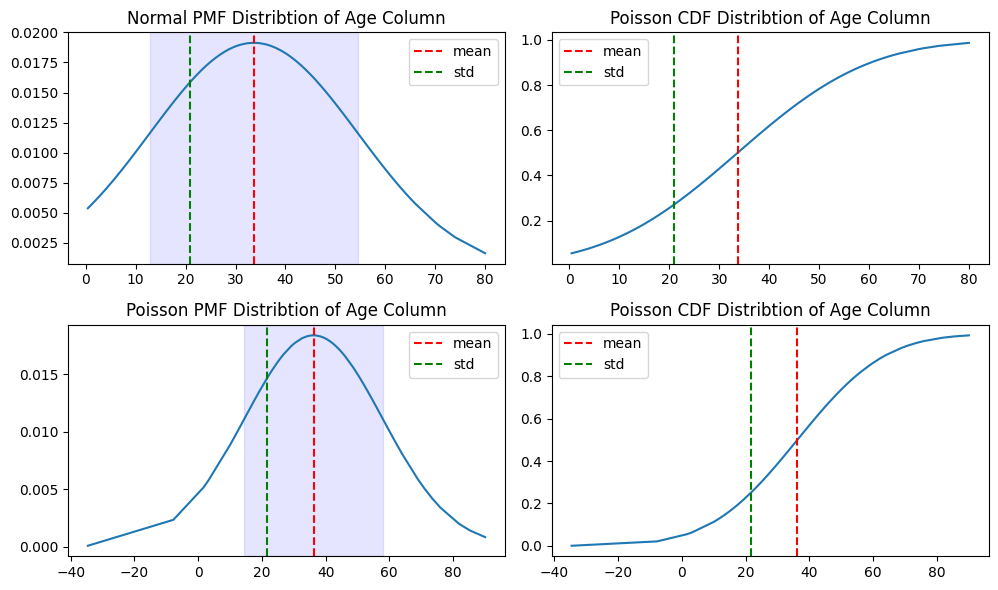

In [141]:
fig,axes = plt.subplots(2,2,figsize=(10,6))
axes[0][0].plot(ages,ages_normal_pdfs)
axes[0][0].axvline(ages.mean(),color="red",linestyle="--",label="mean")
axes[0][0].axvline(ages.std(),color="green",linestyle="--",label="std")
axes[0][0].axvspan(abs(ages.mean()-ages.std()),abs(ages.mean()+ages.std()),alpha=0.1,color="blue")
axes[0][0].set_title("Normal PMF Distribtion of Age Column")
axes[0][0].legend()
axes[0][1].plot(ages,ages_normal_cdfs)
axes[0][1].axvline(ages.mean(),color="red",linestyle="--",label="mean")
axes[0][1].axvline(ages.std(),color="green",linestyle="--",label="std")
axes[0][1].set_title("Poisson CDF Distribtion of Age Column")
axes[0][1].legend()


axes[1][0].plot(th_norm_samples,th_norm_pdfs)
axes[1][0].axvline(th_norm_samples.mean(),color="red",linestyle="--",label="mean")
axes[1][0].axvline(th_norm_samples.std(),color="green",linestyle="--",label="std")
axes[1][0].axvspan(abs(th_norm_samples.mean()-th_norm_samples.std()),
                   abs(th_norm_samples.mean()+th_norm_samples.std()),alpha=0.1,color="blue")
axes[1][0].set_title("Poisson PMF Distribtion of Age Column")
axes[1][0].legend()
axes[1][1].plot(th_norm_samples,norm.cdf(th_norm_samples,loc=th_norm_samples.mean(),scale=th_norm_samples.std()))
axes[1][1].axvline(th_norm_samples.mean(),color="red",linestyle="--",label="mean")
axes[1][1].axvline(th_norm_samples.std(),color="green",linestyle="--",label="std")
axes[1][1].set_title("Poisson CDF Distribtion of Age Column")
axes[1][1].legend()
plt.tight_layout()
plt.savefig("age_column_poisson_dist_graph.png")

In [142]:
"tharun".capitalize()

'Tharun'

In [152]:
cdfs = """[6.21744406e-06 6.21744406e-06 6.21744406e-06 6.21744406e-06
 6.21744406e-06 8.07531064e-05 8.07531064e-05 8.07531064e-05
 8.07531064e-05 8.07531064e-05 8.07531064e-05 8.07531064e-05
 8.07531064e-05 8.07531064e-05 8.07531064e-05 5.27525518e-04
 5.27525518e-04 5.27525518e-04 5.27525518e-04 5.27525518e-04
 5.27525518e-04 5.27525518e-04 5.27525518e-04 5.27525518e-04
 5.27525518e-04 2.31285066e-03 2.31285066e-03 2.31285066e-03
 2.31285066e-03 2.31285066e-03 2.31285066e-03 2.31285066e-03
 2.31285066e-03 2.31285066e-03 2.31285066e-03 7.66353781e-03
 7.66353781e-03 7.66353781e-03 7.66353781e-03 7.66353781e-03
 7.66353781e-03 7.66353781e-03 7.66353781e-03 7.66353781e-03
 7.66353781e-03 2.04925076e-02 2.04925076e-02 2.04925076e-02
 2.04925076e-02 2.04925076e-02 2.04925076e-02 2.04925076e-02
 2.04925076e-02 2.04925076e-02 2.04925076e-02 4.61251135e-02
 4.61251135e-02 4.61251135e-02 4.61251135e-02 4.61251135e-02
 4.61251135e-02 4.61251135e-02 4.61251135e-02 4.61251135e-02
 4.61251135e-02 9.00233374e-02 9.00233374e-02 9.00233374e-02
 9.00233374e-02 9.00233374e-02 9.00233374e-02 9.00233374e-02
 9.00233374e-02 9.00233374e-02 9.00233374e-02 1.55805658e-01
 1.55805658e-01 1.55805658e-01 1.55805658e-01 1.55805658e-01
 1.55805658e-01 1.55805658e-01 1.55805658e-01 1.55805658e-01
 1.55805658e-01 2.43428818e-01 2.43428818e-01 2.43428818e-01
 2.43428818e-01 2.43428818e-01 2.43428818e-01 2.43428818e-01
 2.43428818e-01 2.43428818e-01 2.43428818e-01 3.48472790e-01
 3.48472790e-01 3.48472790e-01 3.48472790e-01 3.48472790e-01
 3.48472790e-01 3.48472790e-01 3.48472790e-01 3.48472790e-01
 3.48472790e-01 4.62953070e-01 4.62953070e-01 4.62953070e-01
 4.62953070e-01 4.62953070e-01 4.62953070e-01 4.62953070e-01
 4.62953070e-01 4.62953070e-01 5.77320316e-01 5.77320316e-01
 5.77320316e-01 5.77320316e-01 5.77320316e-01 5.77320316e-01
 5.77320316e-01 5.77320316e-01 5.77320316e-01 5.77320316e-01
 6.82785846e-01 6.82785846e-01 6.82785846e-01 6.82785846e-01
 6.82785846e-01 6.82785846e-01 6.82785846e-01 6.82785846e-01
 6.82785846e-01 6.82785846e-01 7.73095615e-01 7.73095615e-01
 7.73095615e-01 7.73095615e-01 7.73095615e-01 7.73095615e-01
 7.73095615e-01 7.73095615e-01 8.45272096e-01 8.45272096e-01
 8.45272096e-01 8.45272096e-01 8.45272096e-01 8.45272096e-01
 8.45272096e-01 8.45272096e-01 8.45272096e-01 8.99351008e-01
 8.99351008e-01 8.99351008e-01 8.99351008e-01 8.99351008e-01
 8.99351008e-01 8.99351008e-01 9.37486667e-01 9.37486667e-01
 9.37486667e-01 9.37486667e-01 9.37486667e-01 9.37486667e-01
 9.37486667e-01 9.37486667e-01 9.62885337e-01 9.62885337e-01
 9.62885337e-01 9.62885337e-01 9.62885337e-01 9.62885337e-01
 9.62885337e-01 9.62885337e-01 9.78910764e-01 9.78910764e-01
 9.78910764e-01 9.78910764e-01 9.88516527e-01 9.88516527e-01
 9.88516527e-01 9.88516527e-01 9.88516527e-01 9.94000114e-01
 9.94000114e-01 9.96988208e-01 9.96988208e-01 9.96988208e-01
 9.96988208e-01 9.98545675e-01 9.98545675e-01 9.98545675e-01
 9.98545675e-01 9.98545675e-01 9.98545675e-01 9.99696693e-01
 9.99696693e-01 9.99696693e-01 9.99696693e-01 9.99945075e-01
 9.99977774e-01 9.99977774e-01 9.99977774e-01 9.99977774e-01
 9.99991291e-01 9.99996693e-01 9.99996693e-01 9.99998782e-01
 9.99998782e-01 9.99999564e-01 9.99999564e-01]""".replace(" ",",").replace("\n","")

In [154]:
cdfs = [6.21744406e-06,6.21744406e-06,6.21744406e-06,6.21744406e-06,6.21744406e-06,8.07531064e-05,8.07531064e-05,8.07531064e-05,8.07531064e-05,8.07531064e-05,8.07531064e-05,8.07531064e-05,8.07531064e-05,8.07531064e-05,8.07531064e-05,5.27525518e-04,5.27525518e-04,5.27525518e-04,5.27525518e-04,5.27525518e-04,5.27525518e-04,5.27525518e-04,5.27525518e-04,5.27525518e-04,5.27525518e-04,2.31285066e-03,2.31285066e-03,2.31285066e-03,2.31285066e-03,2.31285066e-03,2.31285066e-03,2.31285066e-03,2.31285066e-03,2.31285066e-03,2.31285066e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,7.66353781e-03,2.04925076e-02,2.04925076e-02,2.04925076e-02,2.04925076e-02,2.04925076e-02,2.04925076e-02,2.04925076e-02,2.04925076e-02,2.04925076e-02,2.04925076e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,4.61251135e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,9.00233374e-02,1.55805658e-01,1.55805658e-01,1.55805658e-01,1.55805658e-01,1.55805658e-01,1.55805658e-01,1.55805658e-01,1.55805658e-01,1.55805658e-01,1.55805658e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,2.43428818e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,3.48472790e-01,4.62953070e-01,4.62953070e-01,4.62953070e-01,4.62953070e-01,4.62953070e-01,4.62953070e-01,4.62953070e-01,4.62953070e-01,4.62953070e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,5.77320316e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,6.82785846e-01,7.73095615e-01,7.73095615e-01,7.73095615e-01,7.73095615e-01,7.73095615e-01,7.73095615e-01,7.73095615e-01,7.73095615e-01,8.45272096e-01,8.45272096e-01,8.45272096e-01,8.45272096e-01,8.45272096e-01,8.45272096e-01,8.45272096e-01,8.45272096e-01,8.45272096e-01,8.99351008e-01,8.99351008e-01,8.99351008e-01,8.99351008e-01,8.99351008e-01,8.99351008e-01,8.99351008e-01,9.37486667e-01,9.37486667e-01,9.37486667e-01,9.37486667e-01,9.37486667e-01,9.37486667e-01,9.37486667e-01,9.37486667e-01,9.62885337e-01,9.62885337e-01,9.62885337e-01,9.62885337e-01,9.62885337e-01,9.62885337e-01,9.62885337e-01,9.62885337e-01,9.78910764e-01,9.78910764e-01,9.78910764e-01,9.78910764e-01,9.88516527e-01,9.88516527e-01,9.88516527e-01,9.88516527e-01,9.88516527e-01,9.94000114e-01,9.94000114e-01,9.96988208e-01,9.96988208e-01,9.96988208e-01,9.96988208e-01,9.98545675e-01,9.98545675e-01,9.98545675e-01,9.98545675e-01,9.98545675e-01,9.98545675e-01,9.99696693e-01,9.99696693e-01,9.99696693e-01,9.99696693e-01,9.99945075e-01,9.99977774e-01,9.99977774e-01,9.99977774e-01,9.99977774e-01,9.99991291e-01,9.99996693e-01,9.99996693e-01,9.99998782e-01,9.99998782e-01,9.99999564e-01,9.99999564e-01]

In [157]:
cdfs[-1]

0.999999564

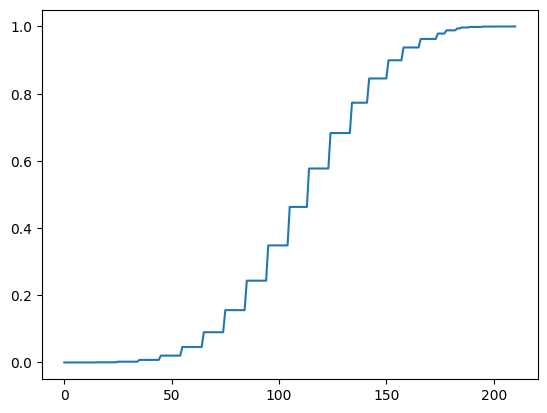

In [158]:
plt.plot(cdfs)

In [159]:
from scipy.stats import expon

In [161]:
expon_scale = 1/ages.mean()

Help on method pdf in module scipy.stats._distn_infrastructure:

pdf(x, *args, **kwds) method of scipy.stats._continuous_distns.expon_gen instance
    Probability density function at x of the given RV.
    
    Parameters
    ----------
    x : array_like
        quantiles
    arg1, arg2, arg3,... : array_like
        The shape parameter(s) for the distribution (see docstring of the
        instance object for more information)
    loc : array_like, optional
        location parameter (default=0)
    scale : array_like, optional
        scale parameter (default=1)
    
    Returns
    -------
    pdf : ndarray
        Probability density function evaluated at x



In [173]:
ages_expon_pdfs.sum()

33.679763558524826

In [181]:
titanic["Sex"]

0        male
1      female
2      female
3      female
4        male
        ...  
886      male
887    female
888    female
889      male
890      male
Name: Sex, Length: 891, dtype: object

In [182]:
from scipy.stats import binom

In [183]:
p = 0.5

In [189]:
binom.rvs(100,0.7,size=10)

array([65, 67, 67, 73, 76, 73, 78, 69, 64, 73])

In [190]:
titanic["Sex"].value_counts(normalize=True)

Sex
male      0.647587
female    0.352413
Name: proportion, dtype: float64

In [194]:
binom.rvs(891,0.64,size=1)

array([567])

In [192]:
titanic["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [203]:
th_samples = binom.rvs(len(titanic["Sex"]),0.5,size=1)[0]

<BarContainer object of 2 artists>

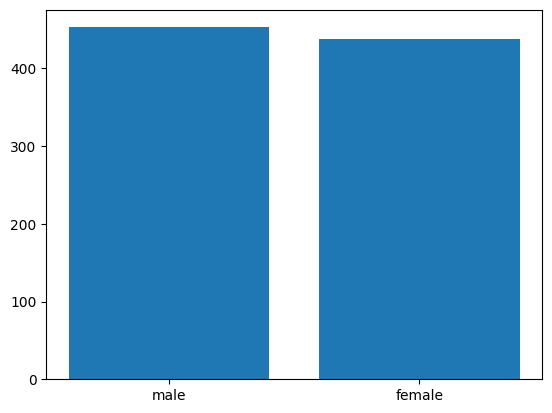

In [204]:
plt.bar(["male","female"],[th_samples,(titanic["Sex"]).shape[0]-th_samples])

In [202]:
[th_samples,(titanic["Sex"]).shape[0]-th_samples]

[array([429]), array([462])]

<BarContainer object of 2 artists>

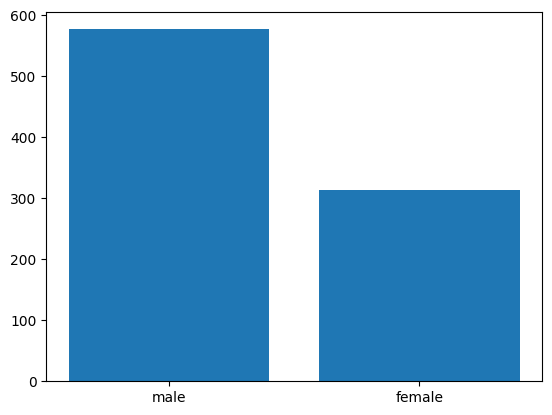

In [207]:
plt.bar(["male","female"],titanic["Sex"].value_counts().values)

In [214]:
df = pd.DataFrame(titanic["Sex"].value_counts())
df["th_samples"] = [binom.rvs(titanic["Sex"].shape[0],0.5,size=1)[0],titanic["Sex"].shape[0]- binom.rvs(titanic["Sex"].shape[0],0.5,size=1)[0]]

In [220]:
df.rename(columns={"count":"actual_samples"},inplace=True)
df.index = ["heart_attack","no_heart_attack"]

<Axes: >

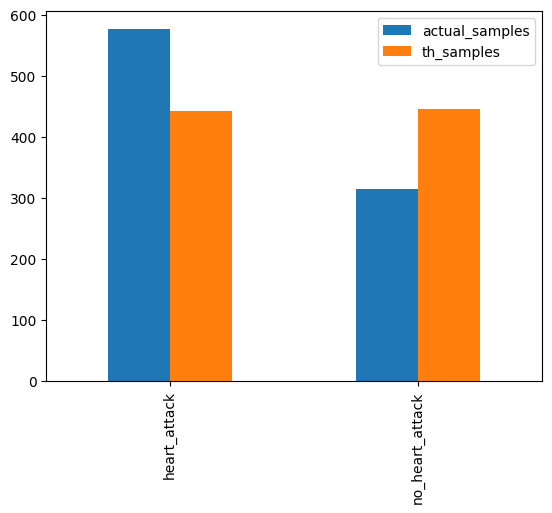

In [221]:
df.plot.bar()

In [222]:
df

,actual_samples,th_samples
heart_attack,577,443
no_heart_attack,314,446


In [223]:
## Percentage of increase in heart_attacks with ideal case

In [226]:
((df["actual_samples"]["heart_attack"]-df["th_samples"]["heart_attack"])/df["th_samples"]["heart_attack"])*100

30.248306997742663

In [227]:
df.index = ["TATA Salt Used","TATA Salt not used"]

<Axes: >

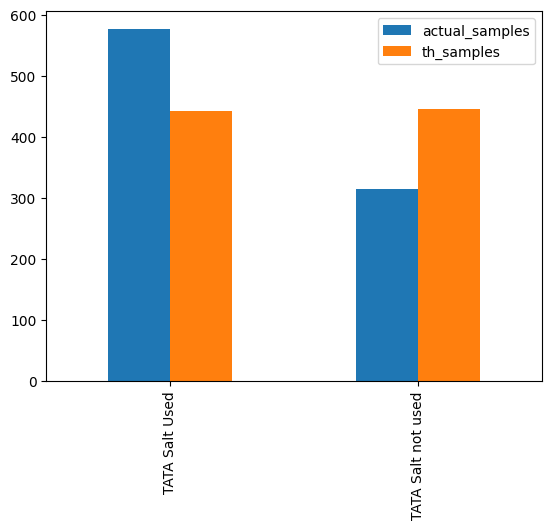

In [229]:
df.plot.bar()

In [236]:
titanic["Pclass"].value_counts(normalize=True)

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

In [232]:
probs = [1/3]*3

In [233]:
from scipy.stats import multinomial

In [235]:
multinomial.rvs(1000,probs,size=1)

array([[320, 346, 334]])

In [247]:
df = pd.DataFrame(titanic["Pclass"].value_counts())
df

,count
Pclass,
3,491
1,216
2,184


In [249]:
df["th_samples"] = multinomial.rvs(titanic.shape[0],[1/df.shape[0]]*df.shape[0],size=1)[0]

In [242]:
[1/df.shape[0]]*df.shape[0]

[0.3333333333333333, 0.3333333333333333, 0.3333333333333333]

In [243]:
titanic.shape[0]

891

In [250]:
df

,count,th_samples
Pclass,,
3,491,333
1,216,282
2,184,276


(array([0, 1, 2]), [Text(0, 0, '3'), Text(1, 0, '1'), Text(2, 0, '2')])

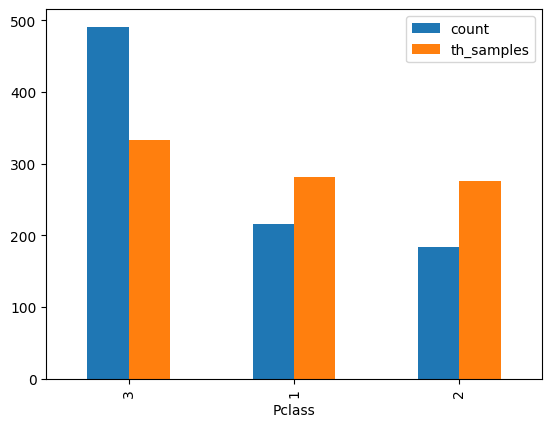

In [255]:
df.plot.bar()
plt.xticks(rotation=90)

In [252]:
uber = pd.read_csv("My_Uber_Drives_2016.csv")

In [254]:
uber["CATEGORY*"].value_counts()

CATEGORY*
Business    1078
Personal      77
Name: count, dtype: int64

In [256]:
titanic["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

<Axes: ylabel='Frequency'>

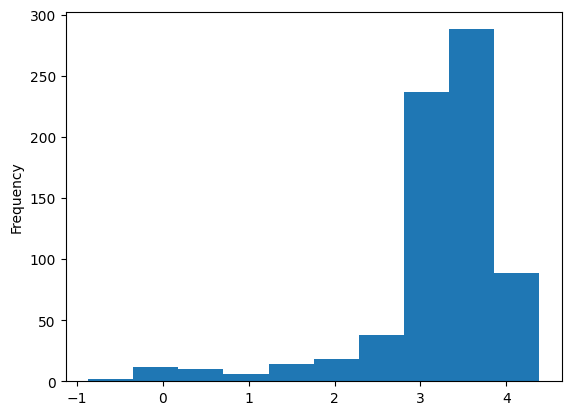

In [260]:
np.log(titanic["Age"]+1e-5).plot.hist()

<Axes: ylabel='Frequency'>

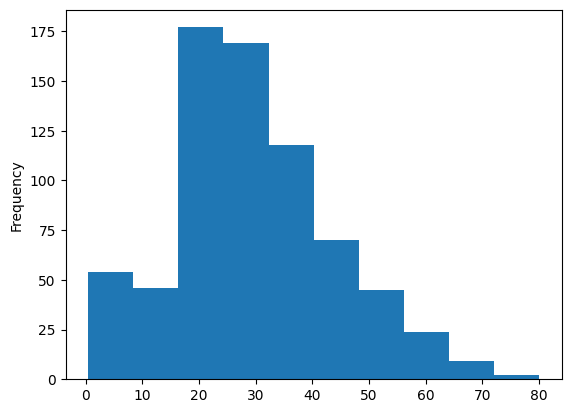

In [261]:
titanic["Age"].plot.hist()

In [262]:
from scipy.stats import boxcox

(array([301., 196.,  93.,  60.,  29.,  16.,  12.,   5.,   1.,   1.]),
 array([-4.11800000e-01,  3.19579380e+02,  6.39570560e+02,  9.59561740e+02,
         1.27955292e+03,  1.59954410e+03,  1.91953528e+03,  2.23952646e+03,
         2.55951764e+03,  2.87950882e+03,  3.19950000e+03]),
 <BarContainer object of 10 artists>)

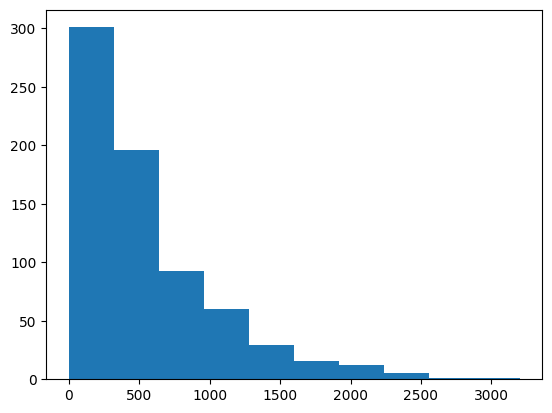

In [265]:
plt.hist(boxcox(titanic["Age"],2))

In [266]:
titanic["Age_log_transform"] = np.log(titanic["Age"])

In [268]:
### Standard Normalization
## Normalization, Batch Noramlization

In [269]:
titanic["Age"]

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888     NaN
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64

In [274]:
def std_normalize(args):
    x = args[0]
    mu = args[1]
    std = args[2]
    return (x-mu)/std

In [275]:
mu = titanic["Age"].mean()
std = titanic["Age"].std()

<Axes: ylabel='Frequency'>

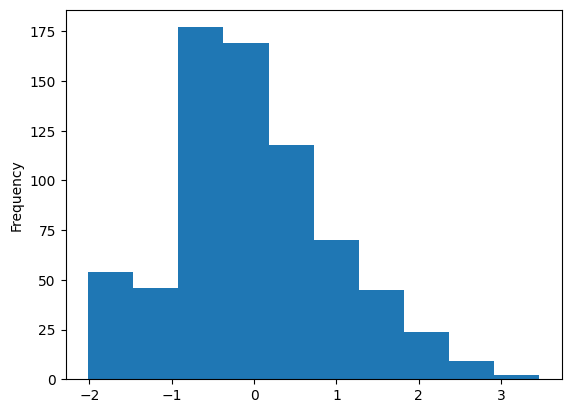

In [277]:
titanic["Age"].apply(lambda x:(x,mu,std)).apply(std_normalize).plot.hist()

In [278]:
## Min Max Transformation

In [279]:
def min_max_transform(args):
    x = args[0]
    min_ = args[1]
    max_ = agrs[2]
    return (x-min_)/(max_-min_)

<Axes: ylabel='Frequency'>

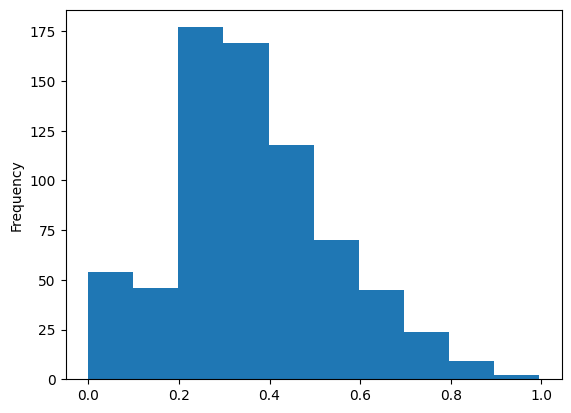

In [280]:
min_ = titanic["Age"].min()
max_ = titanic["Age"].max()
titanic["Age"].apply(lambda x:(x,min_,max_)).apply(std_normalize).plot.hist()

In [285]:
titanic["Embarked"]

array(['S', 'C', 'Q', nan], dtype=object)

In [286]:
titanic["Embarked"]

0      S
1      C
2      S
3      S
4      S
      ..
886    S
887    S
888    S
889    C
890    Q
Name: Embarked, Length: 891, dtype: object